# [Regularisation](https://en.wikipedia.org/wiki/Regularization_(mathematics))

- Ce sont des techniques (générale) pour la réduction d'overfitting
    - =à performance égale sur le train (vs sans) il y aura une amélioration de la généralisation

- L'idée générale est de mettre des "bâtons dans les roues" de l'algorithme ; il doit faire au mieux malgré les difficultés.

### recap
- Chaque couche correspond fait un feature engineering : nouvelles "colonnes" sur base des anciennes.
 

### documentation Keras
- https://keras.io/api/layers/regularization_layers/

In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from keras.layers import (Dense, Flatten, Reshape, Convolution2D, MaxPooling2D, InputLayer,
                                        ## data augmentation:
                                        Rescaling, RandomRotation, RandomFlip,
                                        ## regularization:
                                        Dropout, ActivityRegularization
) 

from keras.datasets import mnist

import keras

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

(X_train, y_train), (X_test, y_test) = mnist.load_data()


print(X_train.shape)
print(y_train.shape)

(60000, 28, 28)
(60000,)



## Dropout

- une partie des neurones sont "désactivé" (=poids $w$ mis à 0)
- cela permet de désactiver une feature parmi les "colonnes" possible
- c'est un peu comme un random forest: chaque arbre de décision ne voit qu'une partie des colonnes disponibles  

[source image](https://stanford.edu/~shervine/teaching/cs-230/cheatsheet-deep-learning-tips-and-tricks#regularization)
<img src="repos/dropout.png" alt="drawing" style="width:600px;"/>

## Régularisation L1,L2
- ajouter à la fonction objective/loss (objective function) $L(w,b|x,y)$  un élément qui contient la valeur des poids $w$
    - exemple de la fonction objective: $L(w,b|x,y) = || y - wx - b ||^2$ le mean square error (MSE)

- Lasso = L1
    - $L(w,b|x,y) = ... + \alpha (\sum_i |w_i|)$
- Ridge =L2
    -  $L(w,b|x,y) = ... + \beta (\sum_i |w_i|^2)$
- Elastic Net = combinaison L1 + L2
    -  $L(w,b|x,y) = ... + \alpha (\sum_i |w_i|)  + \beta (\sum_j |w_j|^2)$



[source image](https://stanford.edu/~shervine/teaching/cs-230/cheatsheet-deep-learning-tips-and-tricks#regularization)
<img src="repos/penalty.png" alt="drawing" style="width:800px;"/>


## Callbacks: Early stopping

### callback
- un paramètre de fonction qui est lui-même une fonction


### early stopping
- Arrêter l'entrainement lorsque le score de validation augmente


[source image](https://stanford.edu/~shervine/teaching/cs-230/cheatsheet-deep-learning-tips-and-tricks#regularization)
<img src="repos/early-stopping.png" alt="drawing" style="width:800px;"/>



In [55]:
callback_early_stopping = keras.callbacks.EarlyStopping(monitor='loss' ## comparer avec la loss
                                                        ,patience=4 ## continuer pendant 3 epoch, avan de s'arreter
                                                        ,start_from_epoch = 2
                                                       )

## callback: variable learning rate
### [recap: learning rate](https://en.wikipedia.org/wiki/Learning_rate)
- La technique de descente de gradient mets à jour les poids $w$ en utilisant le gradient (la pente). L'importance de cette pente dans la mise à jour est déterminée par le learning rate $\lambda$.
    - $w_{t+1} = w_{t} - \lambda \cdot (\nabla L(w,b|x,y))$

    - dans le graphique-ci desous:  $J(\theta) = L(w,b|x,y)$; $\theta = (w,b)$

[source](https://www.jeremyjordan.me/nn-learning-rate/)
<img src="repos/learning-rate.png" alt="drawing" style="width:800px;"/>

In [51]:
def my_learning_rates(epoch, lr):
    """ lr = inital learning rate"""

    if epoch<3:
        return lr
        
    elif epoch<5:
        return lr*0.75
    else: 
        return np.exp(-epoch)*lr

callback_learning_rate = keras.callbacks.LearningRateScheduler(my_learning_rates,verbose=1)

In [52]:
def get_preprocessing(shape: tuple) -> keras.Sequential:
    preprocessor = keras.Sequential([
        Reshape(shape),
        Rescaling(1./255),

        # RandomFlip(),
        RandomRotation(.05),
    ])

    return preprocessor

def get_model(n_class: int, activation: str = 'relu') -> keras.Sequential:

    preprocessor = get_preprocessing((28, 28, 1))

    model = tf.keras.Sequential([
        ### integrer le modele "get_preprocessing" dans le modele pricipale
        InputLayer((28,28)),
        preprocessor,
        
        
        Convolution2D(filters=32, kernel_size=3, activation=activation),
        MaxPooling2D(2),

        Convolution2D(filters=64, kernel_size=3, activation=activation),
        MaxPooling2D(2),
        
    
        Flatten(),
        
        # ActivityRegularization(l1=0.001), ## reduction des neurones inutiles
        
        Dense(units=128, activation=activation),
        
        Dropout(.1), ## 10% des poids entre les deux couches sont mis à 0 (durant l'entrainement)
        
        Dense(units=128, activation=activation),
        Dropout(.3), ## 30% des poids entre les deux couches sont mis à 0 (durant l'entrainement)

        Dense(units=n_class, activation='softmax')
    ])

    model.compile(optimizer=tf.keras.optimizers.Adam(),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy']
                 ,
                 )

    return model


def plot_lc(history: dict, metrics: list = ['loss', 'accuracy']) -> None:
    plt.figure(figsize=(20, 8))
    for i, metric in enumerate(metrics):
        plt.subplot(1, 2, i+1)
        plt.title(f'Learning curve for {metric}\n')
        plt.plot(history[metric], label='train')
        plt.plot(history[f'val_{metric}'], label='val')
        plt.xlabel('epochs')
        plt.ylabel(metric)
        plt.legend()
        if metric == 'accuracy':
            plt.ylim(0,1.1)
    plt.show()




def plot_cm_display(y_true: np.array, y_pred: np.array) -> None:
    cm = confusion_matrix(y_true, y_pred)
    
    #plt.figure(figsize=(20, 8))
    #plt.title('Confusion Matrix\n')
    CM = ConfusionMatrixDisplay(cm)
    CM.plot()
    #sns.heatmap(cm, cmap='vlag', annot=True, fmt='d', cbar=False)
    #plt.xlabel('y_pred')
    #plt.ylabel('y_true')
    plt.show()

In [53]:
cnn = get_model(10)
cnn.fit(X_train, y_train, validation_split=.2, epochs=10, batch_size=256
        ,callbacks=[callback_early_stopping,callback_learning_rate]
       )


Epoch 1: LearningRateScheduler setting learning rate to 0.0010000000474974513.
Epoch 1/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 13s 55ms/step - accuracy: 0.8502 - loss: 0.4808 - val_accuracy: 0.9735 - val_loss: 0.0862 - learning_rate: 0.0010

Epoch 2: LearningRateScheduler setting learning rate to 0.0010000000474974513.
Epoch 2/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 10s 55ms/step - accuracy: 0.9612 - loss: 0.1292 - val_accuracy: 0.9814 - val_loss: 0.0594 - learning_rate: 0.0010

Epoch 3: LearningRateScheduler setting learning rate to 0.0010000000474974513.
Epoch 3/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 11s 58ms/step - accuracy: 0.9728 - loss: 0.0908 - val_accuracy: 0.9839 - val_loss: 0.0535 - learning_rate: 0.0010

Epoch 4: LearningRateScheduler setting learning rate to 0.0007500000356230885.
Epoch 4/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 11s 58ms/step - accuracy: 0.9790 - loss: 0.0700 - val_accuracy: 0.9871 - val_loss: 0.0440 - learning_rate: 7.5000e-04

Epoch 5: LearningRateScheduler setting learning rate to 0.0

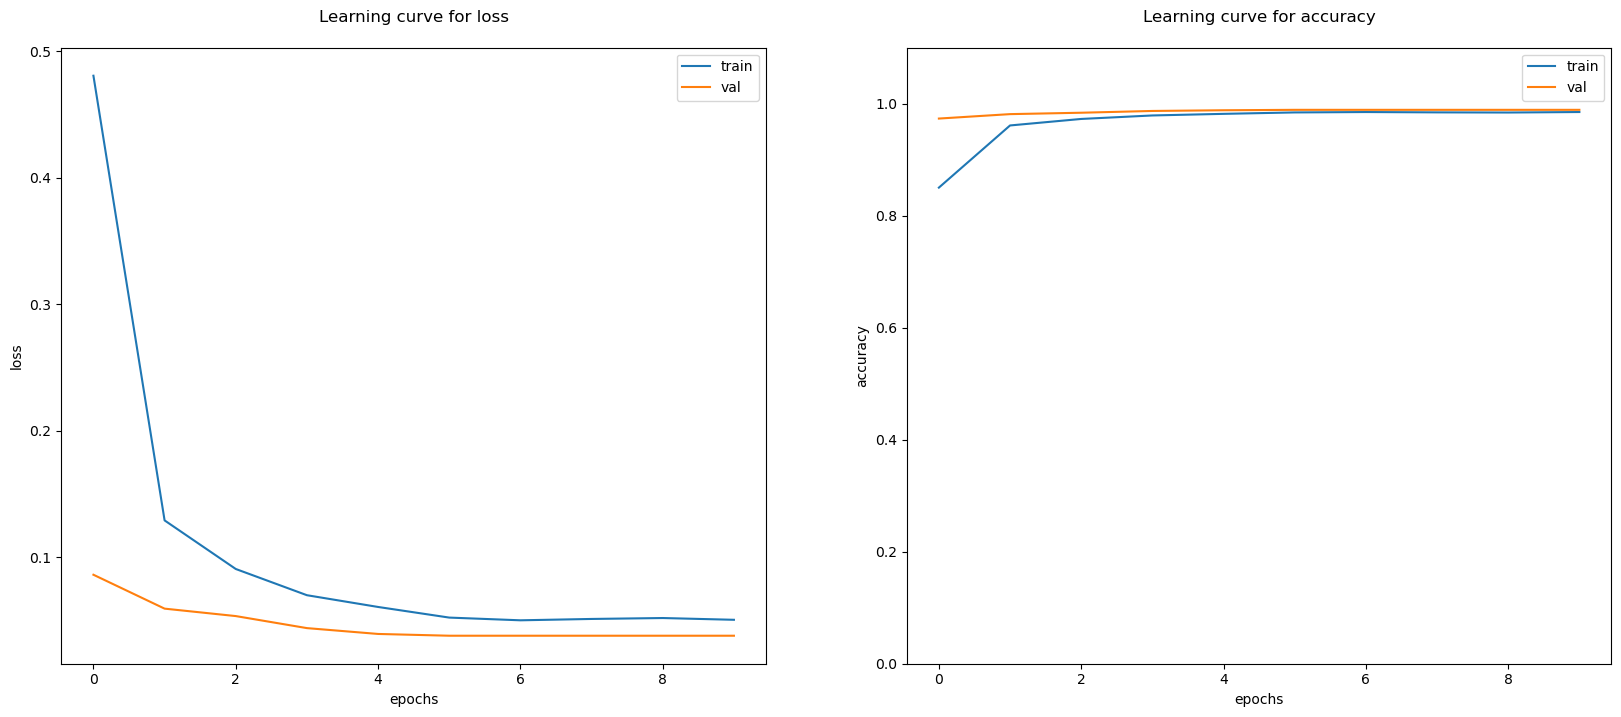

In [54]:
plot_lc(cnn.history.history)

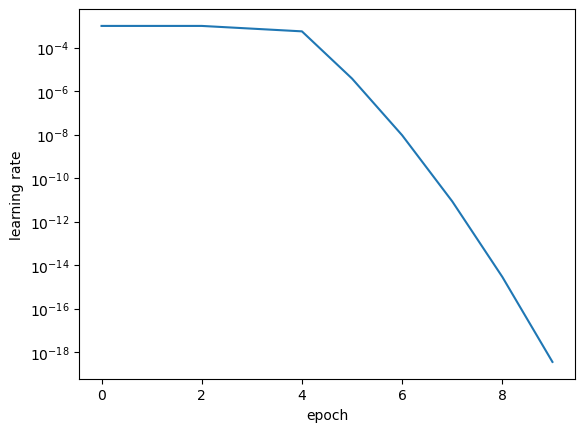

In [63]:
plt.semilogy(cnn.history.history['learning_rate'])
plt.xlabel("epoch")
plt.ylabel("learning rate")
plt.show()